In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline

import seaborn as sns


import os, sys, shutil, importlib, glob
from tqdm.notebook import tqdm
# from celloracle import motif_analysis as ma
# import celloracle as co
import scanpy as sc


In [3]:
df_dar = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv")

In [4]:
df_dar

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Subclass,Sex,Region Subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100456562-100457063,-0.006031,Down,Glut,chr10:100456562-100457063,2.751694e-02
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112328.1,chr10:100642797-100643298,-0.014478,Down,Glut,chr10:100642797-100643298,1.490774e-02
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112713.1,chr10:10107158-10107659,0.030881,Up,Glut,chr10:10107158-10107659,2.347109e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000018909.15,chr7:99535252-99535753,0.001785,Up,GABA,chr7:99535252-99535753,1.977464e-02
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032803.15,chr9:103365644-103366145,0.028069,Up,GABA,chr9:103365644-103366145,4.904168e-02
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032470.17,chr9:99436435-99436936,-0.054067,Down,GABA,chr9:99436435-99436936,3.488255e-02
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,PFC_Sst_Chodl_GABA,M,PFC_Sst_Chodl_GABA,ENSMUSG00000021368.15,chr13:43171217-43171718,NaN,Down,GABA,chr13:43171217-43171718,1.842970e-02


In [5]:
df_full = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE.peak_gene_corr.sig.csv')

In [6]:
df_dar_merge = df_dar.merge(df_full, left_on=['names'], right_on=['peak_id'], how='left',suffixes=('_dar', '_corr'))

In [ ]:
df_dar_merge['ctname'] = df_dar_merge['ctname'].str.replace('.',"-")
#df_dar_merge = df_dar_merge[df_dar_merge['ctname'].str.contains('GABA|Glut', na=False)].copy()

In [9]:
df_deg_all = pd.read_excel("/data2st2/junyi/output/1-1 six_dataset_DEG_list_fdr_FC01_filtered_7region_rmMB 20251227.xlsx",sheet_name="all",index_col=0)
df_deg_CU3RM = df_deg_all[df_deg_all['Model'].str.contains('CUSUS M')].copy()
df_deg_CU3RM = df_deg_CU3RM[df_deg_CU3RM['Region'].isin(['AMY','HPF','PFC'])].copy()
df_deg_CU3RM['ctname'] = df_deg_CU3RM['Region'] + "_" + df_deg_CU3RM['Subclass']
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('/', '-')
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace(' ', '_')
df_deg_CU3RM['targetgene'] = df_deg_CU3RM.index

In [ ]:
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('HPF_HPF_',"HPF_")
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('PFC_PFC_',"PFC_")
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('AMY_AMY_',"AMY_")
#df_deg_CU3RM = df_deg_CU3RM[df_deg_CU3RM['ctname'].str.contains('GABA|Glut', na=False)].copy()

In [11]:
df_deg_CU3RM

,pval,log2FC,ci.hi,ci.lo,FDR,Bonferroni,Subclass,Region,Sex,Method,...,log2FC_Wilcoxon,pval_Wilcoxon,FDR_Wilcoxon,pct_nz_group,comparison_group,Bonferroni_Wilcoxon,Subclass_Wilcoxon,Model,ctname,targetgene
Gene,,,,,,,,,,,,,,,,,,,,,
4930402H24Rik,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.182837,8.127867e-04,4.171538e-02,0.835152,SUS,1.000000e+00,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930402H24Rik
4930544I03Rik,8.507894e-17,0.246177,0.303235,0.189119,2.114743e-14,3.383589e-13,Astrocyte-2,PFC,M,MAST,...,0.784293,6.880562e-16,7.486510e-13,0.363010,SUS,1.122976e-11,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930544I03Rik
4930570B17Rik,1.128117e-06,-0.162081,-0.098318,-0.225843,4.824216e-05,4.486521e-03,Astrocyte-2,PFC,M,MAST,...,-0.410762,1.254829e-06,2.027729e-04,0.412407,SUS,2.048006e-02,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930570B17Rik
4932438H23Rik,3.780038e-10,0.110726,0.144643,0.076810,3.956108e-08,1.503321e-06,Astrocyte-2,PFC,M,MAST,...,0.994446,5.201400e-10,2.358113e-07,0.139001,SUS,8.489205e-06,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4932438H23Rik
9330182L06Rik,9.458295e-09,0.131010,0.176086,0.085934,7.233776e-07,3.761564e-05,Astrocyte-2,PFC,M,MAST,...,0.638395,9.022050e-08,2.265367e-05,0.228030,SUS,1.472489e-03,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,9330182L06Rik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ugdh,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,0.413112,1.056860e-05,4.248527e-04,0.362975,SUS,1.724902e-01,OPC,CUSUS M,AMY_OPC,Ugdh
Vegfa,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,-0.849232,4.784782e-08,4.514014e-06,0.147092,SUS,7.809243e-04,OPC,CUSUS M,AMY_OPC,Vegfa
Wscd1,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,0.354396,1.179816e-04,2.727166e-03,0.284676,SUS,1.000000e+00,OPC,CUSUS M,AMY_OPC,Wscd1


In [109]:
df_deg_merged = df_deg_CU3RM.merge(df_dar_merge, left_on=['targetgene','ctname','Direction'], right_on=['gene_name_dar','ctname','Direction'], how='left', suffixes=('_deg', '_dar'))

In [114]:
df_deg_merged

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,Gene_name_dar,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,nlogp_dar,logfc_scaled_dar
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260,7.491185,0.000328
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,Rnf24,0.214794,0.008986,147.0,0.041158,7.491185,0.000328
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260,7.491185,0.000328
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,Rnf24,0.214794,0.008986,147.0,0.041158,7.491185,0.000328
4,8.507894e-17,0.246177,0.303235,0.189119,2.114743e-14,3.383589e-13,Astrocyte-2,PFC,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30499,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30500,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30501,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30502,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
df_deg_explained = df_deg_merged.dropna(subset=['gene_name_dar'])
num_df_degexplained = df_deg_explained.drop_duplicates(subset=['targetgene','ctname','Direction']).shape[0]

In [111]:
len(df_deg_explained)

17847

In [57]:
df_deg_CU3RM['nlogp'] = -1*np.log(df_deg_CU3RM['FDR']) * np.sign(df_deg_CU3RM['log2FC'])

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [108]:
df_deg_CU3RM

,pval,log2FC,ci.hi,ci.lo,FDR,Bonferroni,Subclass,Region,Sex,Method,...,FDR_Wilcoxon,pct_nz_group,comparison_group,Bonferroni_Wilcoxon,Subclass_Wilcoxon,Model,ctname,targetgene,nlogp,logfc_scaled
Gene,,,,,,,,,,,,,,,,,,,,,
4930402H24Rik,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,4.171538e-02,0.835152,SUS,1.000000e+00,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930402H24Rik,4.623055,0.047225
4930544I03Rik,8.507894e-17,0.246177,0.303235,0.189119,2.114743e-14,3.383589e-13,Astrocyte-2,PFC,M,MAST,...,7.486510e-13,0.363010,SUS,1.122976e-11,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930544I03Rik,31.487258,0.110570
4930570B17Rik,1.128117e-06,-0.162081,-0.098318,-0.225843,4.824216e-05,4.486521e-03,Astrocyte-2,PFC,M,MAST,...,2.027729e-04,0.412407,SUS,2.048006e-02,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930570B17Rik,-9.939277,-0.072798
4932438H23Rik,3.780038e-10,0.110726,0.144643,0.076810,3.956108e-08,1.503321e-06,Astrocyte-2,PFC,M,MAST,...,2.358113e-07,0.139001,SUS,8.489205e-06,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4932438H23Rik,17.045420,0.049733
9330182L06Rik,9.458295e-09,0.131010,0.176086,0.085934,7.233776e-07,3.761564e-05,Astrocyte-2,PFC,M,MAST,...,2.265367e-05,0.228030,SUS,1.472489e-03,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,9330182L06Rik,14.139334,0.058843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ugdh,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,4.248527e-04,0.362975,SUS,1.724902e-01,OPC,CUSUS M,AMY_OPC,Ugdh,7.628035,0.065960
Vegfa,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,4.514014e-06,0.147092,SUS,7.809243e-04,OPC,CUSUS M,AMY_OPC,Vegfa,-24.521813,-0.090968
Wscd1,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,2.727166e-03,0.284676,SUS,1.000000e+00,OPC,CUSUS M,AMY_OPC,Wscd1,10.003678,0.068051


In [58]:
df_dar_merge['nlogp'] = -1*np.log(df_dar_merge['FDR_dar'])  * np.sign(df_dar_merge['log2FC'])

In [120]:
shared_absmax = max(
    df_deg_CU3RM['log2FC'].abs().max(),
    df_dar_merge['log2FC'].abs().max()
 )
shared_absmax = 1 if pd.isna(shared_absmax) or shared_absmax == 0 else shared_absmax

df_deg_CU3RM['nlogp_scaled'] = df_deg_CU3RM['nlogp'] / df_deg_CU3RM['nlogp'].abs().max()
df_dar_merge['nlogp_scaled'] = df_dar_merge['nlogp'] / df_dar_merge['nlogp'].abs().max()

In [122]:
df_dar_merge['nlogp_scaled'] 

0        -0.011287
1        -0.011287
2         0.050674
3         0.050674
4        -0.013212
            ...   
883097   -0.010542
883098         NaN
883099         NaN
883100         NaN
883101         NaN
Name: nlogp_scaled, Length: 883102, dtype: float64

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


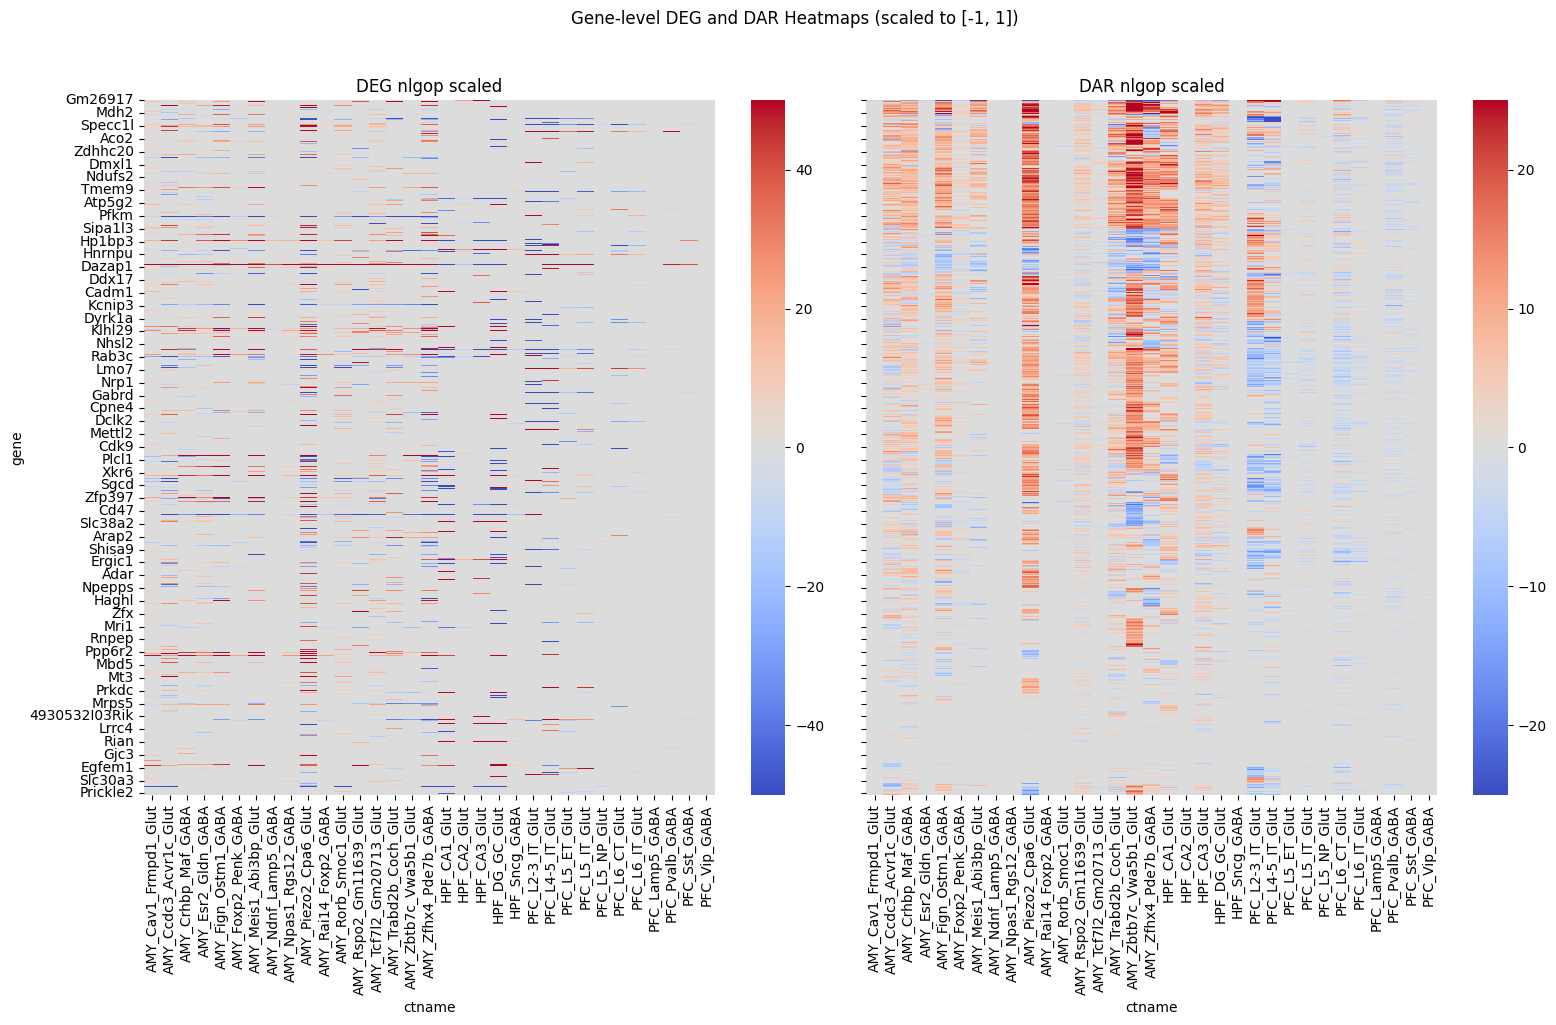

In [128]:
deg_gene_matrix = df_deg_CU3RM.pivot_table(index='targetgene', columns='ctname', values='nlogp', aggfunc='median', fill_value=0)
dar_gene_matrix = df_dar_merge[np.abs(df_dar_merge.coef)>0.01].pivot_table(index='gene_name_dar', columns='ctname', values='nlogp', aggfunc='median', fill_value=0)

shared_genes = deg_gene_matrix.index.intersection(dar_gene_matrix.index)
shared_ctnames = deg_gene_matrix.columns.intersection(dar_gene_matrix.columns)
shared_ctnames = shared_ctnames[shared_ctnames.str.contains('GABA|Glut', na=False)]

deg_gene_matrix = deg_gene_matrix.loc[shared_genes, shared_ctnames]
dar_gene_matrix = dar_gene_matrix.loc[shared_genes, shared_ctnames]

col_order = sorted(shared_ctnames)

deg_gene_matrix = deg_gene_matrix.loc[:, col_order]
dar_gene_matrix = dar_gene_matrix.loc[:, col_order]

deg_gene_matrix = deg_gene_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)
dar_gene_matrix = dar_gene_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)

deg_cluster = sns.clustermap(dar_gene_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1, row_cluster=True, col_cluster=False, figsize=(6, min(10, len(shared_genes) * 0.12)))
row_order = deg_gene_matrix.index[deg_cluster.dendrogram_row.reordered_ind]
plt.close(deg_cluster.fig)

deg_gene_matrix = deg_gene_matrix.loc[row_order]
dar_gene_matrix = dar_gene_matrix.loc[row_order]

fig, axes = plt.subplots(1, 2, figsize=(16, min(10, len(row_order) * 0.12)), sharey=True)
sns.heatmap(deg_gene_matrix, cmap='coolwarm', center=0, ax=axes[0],vmin=-50,vmax=50, cbar=True)
sns.heatmap(dar_gene_matrix, cmap='coolwarm', center=0, ax=axes[1],vmin=-25,vmax=25, cbar=True)
axes[0].set_title('DEG nlgop scaled')
axes[1].set_title('DAR nlgop scaled')
axes[0].set_xlabel('ctname')
axes[1].set_xlabel('ctname')
axes[0].set_ylabel('gene')
axes[1].set_ylabel('')
axes[0].set_xticks(np.arange(len(col_order)) + 0.5)
axes[1].set_xticks(np.arange(len(col_order)) + 0.5)
axes[0].set_xticklabels(col_order, rotation=90)
axes[1].set_xticklabels(col_order, rotation=90)
plt.suptitle('Gene-level DEG and DAR Heatmaps (scaled to [-1, 1])', y=1.02)
plt.tight_layout()

In [8]:
def chrom_sort_key(chrom):
    chrom = str(chrom)
    chrom_body = chrom[3:] if chrom.startswith('chr') else chrom
    if chrom_body.isdigit():
        return (0, int(chrom_body))
    if chrom_body == 'X':
        return (1, 23)
    if chrom_body == 'Y':
        return (2, 24)
    if chrom_body == 'M':
        return (3, 25)
    return (4, chrom_body)



In [21]:
for ctname in df_deg_CU3RM['ctname'].unique():
    df_deg_ct = df_deg_CU3RM[df_deg_CU3RM['ctname'] == ctname].copy()
    df_deg_region = df_full[df_full.gene_name.isin(df_deg_ct['targetgene'].unique())]

    region_col = next((col for col in ['peak_id', 'names', 'region', 'peak'] if col in df_deg_region.columns), None)
    if region_col is None:
        raise KeyError('No genomic region column found in df_deg_region.')

    df_deg_region_bed = df_deg_region.copy()
    region_parts = df_deg_region_bed[region_col].astype(str).str.extract(r'^(?P<chr>chr(?:\d+|X|Y|M)):(?P<start>\d+)-(?P<end>\d+)$')
    df_deg_region_bed = pd.concat([df_deg_region_bed, region_parts], axis=1)
    df_deg_region_bed['start'] = pd.to_numeric(df_deg_region_bed['start'], errors='coerce')
    df_deg_region_bed['end'] = pd.to_numeric(df_deg_region_bed['end'], errors='coerce')
    df_deg_region_bed = df_deg_region_bed.dropna(subset=['chr', 'start', 'end']).copy()
    df_deg_region_bed['start'] = df_deg_region_bed['start'].astype(int)
    df_deg_region_bed['end'] = df_deg_region_bed['end'].astype(int)

    df_deg_region_bed = df_deg_region_bed.sort_values(
        by=['chr', 'start', 'end'],
        key=lambda col: col.map(chrom_sort_key) if col.name == 'chr' else col
    ).reset_index(drop=True)

    bed_cols = ['chr', 'start', 'end', region_col]
    if 'gene_name' in df_deg_region_bed.columns:
        bed_cols.append('gene_name')

    output_bed = f'/data2st1/junyi/output/atac1112/cCRE/L2degpeaks/{ctname}.bed'
    df_deg_region_bed.loc[:, bed_cols].to_csv(output_bed, sep='\t', header=False, index=False)
    df_deg_region_bed.loc[:, bed_cols].head()

In [18]:
df_deg_region_bed

,peak_id,gene_name,correlation,pval,n_samples,FDR,chr,start,end
0,chr1:20477655-20478156,Paqr8,-0.212666,9.707546e-03,147,0.043536,chr1,20477655,20478156
1,chr1:20609659-20610160,Paqr8,-0.215833,8.651812e-03,147,0.040035,chr1,20609659,20610160
2,chr1:20677942-20678443,Paqr8,0.219882,7.450693e-03,147,0.035890,chr1,20677942,20678443
3,chr1:20722698-20723199,Paqr8,0.209467,1.088764e-02,147,0.047327,chr1,20722698,20723199
4,chr1:20724704-20725205,Paqr8,0.306974,1.556926e-04,147,0.001841,chr1,20724704,20725205
...,...,...,...,...,...,...,...,...,...
41058,chrX:155677101-155677602,Sat1,-0.213227,9.512441e-03,147,0.042900,chrX,155677101,155677602
41059,chrX:155679401-155679902,Sat1,-0.240568,3.334778e-03,147,0.019776,chrX,155679401,155679902
41060,chrX:155690395-155690896,Sat1,-0.438929,2.680103e-08,147,0.000001,chrX,155690395,155690896
41061,chrX:155696693-155697194,Sat1,-0.279578,6.048944e-04,147,0.005362,chrX,155696693,155697194


In [6]:
df_full.rename(columns={'peak_id':'names','gene_name':'gene_coaccess'}, inplace=True)

In [7]:
df_peak_gene_select = df_full[['names','gene_coaccess','correlation']].copy()

In [84]:
df_promoter_peak_500kb

,promoter_id,gene_name,gene_id,cCRE,chrom,promoter_start,promoter_end,peak_id,peak_chrom,peak_start,peak_end,distance
0,chr1:3671348-3673348,Xkr4,ENSMUSG00000051951.5,promoter,chr1,3671348,3673348,chr1:3171467-3171968,chr1,3171467,3171968,499380
1,chr1:3671348-3673348,Xkr4,ENSMUSG00000051951.5,promoter,chr1,3671348,3673348,chr1:3174053-3174554,chr1,3174053,3174554,496794
2,chr1:3671348-3673348,Xkr4,ENSMUSG00000051951.5,promoter,chr1,3671348,3673348,chr1:3174697-3175198,chr1,3174697,3175198,496150
3,chr1:3671348-3673348,Xkr4,ENSMUSG00000051951.5,promoter,chr1,3671348,3673348,chr1:3177372-3177873,chr1,3177372,3177873,493475
4,chr1:3671348-3673348,Xkr4,ENSMUSG00000051951.5,promoter,chr1,3671348,3673348,chr1:3181089-3181590,chr1,3181089,3181590,489758
...,...,...,...,...,...,...,...,...,...,...,...,...
9640198,chrX:169977475-169979475,Mid1,ENSMUSG00000035299.16,promoter,chrX,169977475,169979475,chrX:169639840-169640341,chrX,169639840,169640341,337134
9640199,chrX:169977475-169979475,Mid1,ENSMUSG00000035299.16,promoter,chrX,169977475,169979475,chrX:169787102-169787603,chrX,169787102,169787603,189872
9640200,chrX:169977475-169979475,Mid1,ENSMUSG00000035299.16,promoter,chrX,169977475,169979475,chrX:169934728-169935229,chrX,169934728,169935229,42246
9640201,chrX:169977475-169979475,Mid1,ENSMUSG00000035299.16,promoter,chrX,169977475,169979475,chrX:169950963-169951464,chrX,169950963,169951464,26011


In [8]:
df_peak_gene_select

,names,gene_coaccess,correlation
0,chr15:79212774-79213275,Sox10,0.920316
1,chr15:79164315-79164816,Sox10,0.901283
2,chr8:111375106-111375607,Fa2h,0.893897
3,chr3:125898900-125899401,Ugt8a,0.880538
4,chrX:73756675-73757176,Plxnb3,0.876875
...,...,...,...
1595939,chr17:26104123-26104624,Rab11fip3,0.207329
1595940,chr8:58871146-58871647,Galntl6,0.207329
1595941,chr4:107297185-107297686,Hspb11,-0.207329
1595942,chr4:8713041-8713542,Rab2a,0.207329


In [10]:
df_peak_gene_select=df_peak_gene_select[df_peak_gene_select['correlation']>0.45]


In [11]:
df_peak_gene_select

,names,gene_coaccess,correlation
0,chr15:79212774-79213275,Sox10,0.920316
1,chr15:79164315-79164816,Sox10,0.901283
2,chr8:111375106-111375607,Fa2h,0.893897
3,chr3:125898900-125899401,Ugt8a,0.880538
4,chrX:73756675-73757176,Plxnb3,0.876875
...,...,...,...
118358,chr16:35262030-35262531,Adcy5,0.450004
118359,chr10:123458708-123459209,Tafa2,0.450003
118360,chr18:62402272-62402773,Spink13,0.450002
118361,chr17:34121055-34121556,Rab11b,0.450001


In [19]:
df_dar_merge = df_dar.merge(df_peak_gene_select, left_on='names', right_on='names', how='inner')

In [20]:
df_dar_merge.sort_values('correlation', ascending=False,inplace=True)

In [22]:
df_dar_merge.drop_duplicates(subset=['names','gene_coaccess','Region subclass','Region'],keep='first', inplace=True)

In [23]:
df_dar_merge

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Region subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR,gene_coaccess,correlation
67953,chr15:79212774-79213275,3.739881e-06,0.017492,0.062788,-0.027804,5.030887e-02,MOL-2,HPF,HPF_MOL.2,6.863421e-05,...,HPF_MOL-2,ENSMUSG00000075555.12,chr15:79212774-79213275,0.017492,Up,NN,chr15:79212774-79213275,6.863421e-05,Sox10,0.920316
67954,chr15:79212774-79213275,5.951381e-05,0.063997,0.107616,0.020378,5.407424e-01,MOL-1,HPF,HPF_MOL.1,8.610548e-04,...,HPF_MOL-1,ENSMUSG00000075555.12,chr15:79212774-79213275,0.063997,Up,NN,chr15:79212774-79213275,8.610548e-04,Sox10,0.920316
67952,chr15:79212774-79213275,2.741563e-06,-0.124631,-0.076113,-0.173150,3.291246e-02,MOL-1,PFC,PFC_MOL.1,1.205585e-04,...,PFC_MOL-1,ENSMUSG00000075555.12,chr15:79212774-79213275,-0.124631,Down,NN,chr15:79212774-79213275,1.205585e-04,Sox10,0.920316
98299,chr15:79164315-79164816,2.180259e-02,0.006212,0.048243,-0.035819,1.000000e+00,MOL-2,HPF,HPF_MOL.2,2.923237e-02,...,HPF_MOL-2,ENSMUSG00000033006.10,chr15:79164315-79164816,0.006212,Up,NN,chr15:79164315-79164816,2.923237e-02,Sox10,0.901283
98300,chr15:79164315-79164816,4.036992e-05,0.036770,0.075662,-0.002121,3.668011e-01,MOL-1,HPF,HPF_MOL.1,6.938479e-04,...,HPF_MOL-1,ENSMUSG00000033006.10,chr15:79164315-79164816,0.036770,Up,NN,chr15:79164315-79164816,6.938479e-04,Sox10,0.901283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20057,chr17:34121055-34121556,1.161287e-03,0.042914,0.080218,0.005610,1.000000e+00,MOL-1,HPF,HPF_MOL.1,5.065508e-03,...,HPF_MOL-1,ENSMUSG00000037649.10,chr17:34121055-34121556,0.042914,Up,NN,chr17:34121055-34121556,5.065508e-03,Rab11b,0.450001
20048,chr17:34121055-34121556,7.735077e-07,-0.018950,-0.002088,-0.035813,2.411720e-02,PFC_L5_IT_Glut,PFC,PFC_L5_IT_Glut,6.763051e-06,...,PFC_L5_IT_Glut,ENSMUSG00000037649.10,chr17:34121055-34121556,-0.018950,Down,Glut,chr17:34121055-34121556,6.763051e-06,Rab11b,0.450001
20053,chr17:34121055-34121556,1.105458e-03,0.009373,0.020969,-0.002222,1.000000e+00,HPF_DG_GC_Glut,HPF,HPF_DG_GC_Glut,1.541982e-03,...,HPF_DG_GC_Glut,ENSMUSG00000037649.10,chr17:34121055-34121556,0.009373,Up,Glut,chr17:34121055-34121556,1.541982e-03,Rab11b,0.450001
20049,chr17:34121055-34121556,2.093922e-02,0.049236,0.098757,-0.000284,1.000000e+00,Astrocyte-2,HPF,HPF_Astrocyte.2,4.983181e-02,...,HPF_Astrocyte-2,ENSMUSG00000037649.10,chr17:34121055-34121556,0.049236,Up,NN,chr17:34121055-34121556,4.983181e-02,Rab11b,0.450001


In [24]:
df_dar_merge['gene_back']= df_dar_merge['gene_name']

In [25]:
df_dar_merge['gene_name'] = df_dar_merge['gene_coaccess']

In [26]:
df_dar_merge.dropna(subset=['coef'], inplace=True)

In [77]:
df_dar_merge

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR,gene_coaccess,correlation,gene_back
67953,chr15:79212774-79213275,3.739881e-06,0.017492,0.062788,-0.027804,5.030887e-02,MOL-2,HPF,HPF_MOL.2,6.863421e-05,...,ENSMUSG00000075555.12,chr15:79212774-79213275,0.017492,Up,NN,chr15:79212774-79213275,6.863421e-05,Sox10,0.920316,Gm10863
67954,chr15:79212774-79213275,5.951381e-05,0.063997,0.107616,0.020378,5.407424e-01,MOL-1,HPF,HPF_MOL.1,8.610548e-04,...,ENSMUSG00000075555.12,chr15:79212774-79213275,0.063997,Up,NN,chr15:79212774-79213275,8.610548e-04,Sox10,0.920316,Gm10863
67952,chr15:79212774-79213275,2.741563e-06,-0.124631,-0.076113,-0.173150,3.291246e-02,MOL-1,PFC,PFC_MOL.1,1.205585e-04,...,ENSMUSG00000075555.12,chr15:79212774-79213275,-0.124631,Down,NN,chr15:79212774-79213275,1.205585e-04,Sox10,0.920316,Gm10863
98299,chr15:79164315-79164816,2.180259e-02,0.006212,0.048243,-0.035819,1.000000e+00,MOL-2,HPF,HPF_MOL.2,2.923237e-02,...,ENSMUSG00000033006.10,chr15:79164315-79164816,0.006212,Up,NN,chr15:79164315-79164816,2.923237e-02,Sox10,0.901283,Sox10
98300,chr15:79164315-79164816,4.036992e-05,0.036770,0.075662,-0.002121,3.668011e-01,MOL-1,HPF,HPF_MOL.1,6.938479e-04,...,ENSMUSG00000033006.10,chr15:79164315-79164816,0.036770,Up,NN,chr15:79164315-79164816,6.938479e-04,Sox10,0.901283,Sox10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20057,chr17:34121055-34121556,1.161287e-03,0.042914,0.080218,0.005610,1.000000e+00,MOL-1,HPF,HPF_MOL.1,5.065508e-03,...,ENSMUSG00000037649.10,chr17:34121055-34121556,0.042914,Up,NN,chr17:34121055-34121556,5.065508e-03,Rab11b,0.450001,H2-DMa
20048,chr17:34121055-34121556,7.735077e-07,-0.018950,-0.002088,-0.035813,2.411720e-02,PFC_L5_IT_Glut,PFC,PFC_L5_IT_Glut,6.763051e-06,...,ENSMUSG00000037649.10,chr17:34121055-34121556,-0.018950,Down,Glut,chr17:34121055-34121556,6.763051e-06,Rab11b,0.450001,H2-DMa
20053,chr17:34121055-34121556,1.105458e-03,0.009373,0.020969,-0.002222,1.000000e+00,HPF_DG_GC_Glut,HPF,HPF_DG_GC_Glut,1.541982e-03,...,ENSMUSG00000037649.10,chr17:34121055-34121556,0.009373,Up,Glut,chr17:34121055-34121556,1.541982e-03,Rab11b,0.450001,H2-DMa
20049,chr17:34121055-34121556,2.093922e-02,0.049236,0.098757,-0.000284,1.000000e+00,Astrocyte-2,HPF,HPF_Astrocyte.2,4.983181e-02,...,ENSMUSG00000037649.10,chr17:34121055-34121556,0.049236,Up,NN,chr17:34121055-34121556,4.983181e-02,Rab11b,0.450001,H2-DMa


In [ ]:
# df_dar_merge['regulattion'] = np.sign(df_dar_merge['correlation']*df_dar_merge['log2FC'])
# df_dar_merge['Direction'] = np.where(df_dar_merge['regulattion'] > 0, 'Up', 'Down')

In [27]:
df_ct=pd.crosstab(df_dar_merge['status'], df_dar_merge['Direction'])

In [28]:
df_ct

Direction,Down,Up
status,,
Down,56928,0
Up,0,33069


In [29]:
df_dar_merge.to_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_corr04.csv", index=False)

In [62]:
def filter_dar(df_r2g,type='q90'):
    df_r2g_pos = df_r2g[df_r2g['rho'] > 0.05].copy()

    cut_85 = df_r2g_pos['importance'].quantile(0.85)
    cut_90 = df_r2g_pos['importance'].quantile(0.90)
    cut_95 = df_r2g_pos['importance'].quantile(0.95)

    df_r2g_q85 = df_r2g_pos[df_r2g_pos['importance'] >= cut_85].copy()
    df_r2g_q90 = df_r2g_pos[df_r2g_pos['importance'] >= cut_90].copy()
    df_r2g_q95 = df_r2g_pos[df_r2g_pos['importance'] >= cut_95].copy()

    df_r2g_top5 = (
        df_r2g_pos
        .sort_values(['target', 'importance'], ascending=[True, False])
        .groupby('target', group_keys=False)
        .head(5)
        .copy()
    )

    if type == 'q85':
        return df_r2g_q85
    elif type == 'q90':
        return df_r2g_q90
    elif type == 'q95':
        return df_r2g_q95
    elif type == 'top5':
        return df_r2g_top5
    else:
        raise ValueError("Invalid type. Choose from 'q85', 'q90', 'q95', 'top5'.")

In [66]:
df_scenicp = pd.DataFrame()
for region in ['HIP','PFC','AMY']:
    for nt in ['GABA', 'Glut', 'NN']:
        if nt == 'NN':
            fname = f"/data2st1/junyi/output/atac1112/scenic/{region}_{nt}/Snakemake/region_to_gene_adj.tsv"
        else:
            fname = f"/data2st1/junyi/output/atac1112/scenic/{region}_{region}_{nt}/Snakemake/region_to_gene_adj.tsv"
        if os.path.exists(fname):
            df_r2g = pd.read_csv(fname, sep='\t')
            df_r2g['Region NT'] = f"{region}_{nt}"
            df_r2g['Distance'] = (
            df_r2g['Distance']
            .astype(str)
            .str.replace(r'[\[\]]', '', regex=True)
        )
        df_selected = filter_dar(df_r2g, type='q90')
        df_scenicp = pd.concat([df_scenicp, df_selected], ignore_index=True)





In [70]:
df_scenicp['Region NT'] = df_scenicp['Region NT'].str.replace('HIP', 'HPF', regex=False)

In [73]:
df_scenicp.rename(columns={'region': 'names', 'target': 'gene_scenic'}, inplace=True)

In [75]:
df_dar_scenicp = df_dar.merge(df_scenicp, left_on=['names', 'Region NT'], right_on=['names', 'Region NT'], how='inner')

In [78]:
df_dar_scenicp.sort_values('rho', ascending=False, inplace=True)

In [80]:
df_dar_scenicp

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Neurotransmitter,Gene_name,FDR,Region NT,gene_scenic,importance,rho,importance_x_rho,importance_x_abs_rho,Distance
19213,chr7:54910081-54910582,1.977764e-06,-0.035931,-0.017479,-0.054383,3.912610e-02,Astrocyte-2,PFC,PFC_Astrocyte.2,6.035184e-06,...,NN,chr7:54910081-54910582,6.035184e-06,PFC_NN,Luzp2,0.042027,0.915262,0.038466,0.038466,0
18167,chr5:9703583-9704084,7.269856e-03,-0.013420,0.006749,-0.033589,1.000000e+00,Astrocyte-2,PFC,PFC_Astrocyte.2,8.422322e-03,...,NN,chr5:9703583-9704084,8.422322e-03,PFC_NN,Grm3,0.021936,0.901140,0.019767,0.019767,0
14888,chr19:22701118-22701619,4.482236e-03,-0.022934,0.000498,-0.046366,1.000000e+00,Astrocyte-2,PFC,PFC_Astrocyte.2,5.371461e-03,...,NN,chr19:22701118-22701619,5.371461e-03,PFC_NN,Trpm3,0.017696,0.899821,0.015923,0.015923,0
58818,chr13:20090323-20090824,4.165566e-03,0.005861,0.036462,-0.024739,1.000000e+00,Microglia-1,AMY,AMY_Microglia.1,1.710623e-02,...,NN,chr13:20090323-20090824,1.710623e-02,AMY_NN,Elmo1,0.030100,0.897853,0.027025,0.027025,22
15353,chr1:168550027-168550528,2.606869e-04,-0.034666,-0.015136,-0.054195,1.000000e+00,Astrocyte-2,PFC,PFC_Astrocyte.2,4.084240e-04,...,NN,chr1:168550027-168550528,4.084240e-04,PFC_NN,Pbx1,0.038998,0.897318,0.034994,0.034994,118008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22386,chr7:81134477-81134978,9.841787e-04,-0.029004,-0.000914,-0.057094,1.000000e+00,PFC_Pvalb_GABA,PFC,PFC_Pvalb_GABA,8.803986e-03,...,GABA,chr7:81134477-81134978,8.803986e-03,PFC_GABA,Alpk3,0.018254,0.050010,0.000913,0.000913,-29116
22384,chr7:81134477-81134978,4.591190e-03,-0.048338,-0.014449,-0.082228,1.000000e+00,PFC_Sst_GABA,PFC,PFC_Sst_GABA,2.768679e-02,...,GABA,chr7:81134477-81134978,2.768679e-02,PFC_GABA,Alpk3,0.018254,0.050010,0.000913,0.000913,-29116
70360,chr5:135713370-135713871,4.617472e-05,0.009453,0.036065,-0.017159,1.000000e+00,Microglia-1,HPF,HPF_Microglia.1,1.006853e-04,...,NN,chr5:135713370-135713871,1.006853e-04,HPF_NN,Tmem120a,0.028231,0.050009,0.001412,0.001412,-21865
57662,chr7:27338857-27339358,2.926037e-19,-0.013196,-0.006910,-0.019482,7.605648e-15,PFC_L2-3_IT_Glut,PFC,PFC_L2.3_IT_Glut,4.399635e-19,...,Glut,chr7:27338857-27339358,4.399635e-19,PFC_Glut,Numbl,0.040099,0.050007,0.002005,0.002005,-56964
